
# 🎰 The Casino Challenge — Multi‑Armed Bandits & ε‑Greedy (Gamified Workshop)

**Goal:** Compete to maximize reward while learning the exploration–exploitation trade‑off using **ε‑greedy** policies.

**You will:**
- Implement and *play* with ε‑greedy on a fixed set of bandit arms (Round 1: Stationary).
- Compete on a leaderboard (submit your score locally).
- Reflect on how exploration affects performance.
- Face a twist (Round 2: **Non‑Stationary** bandits) and adapt your strategy.



## 🔧 Setup

Run the cell below. If you're on Colab/Jupyter, required libraries should already be available.


In [3]:

import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path
from datetime import datetime

plt.rcParams['figure.figsize'] = (8, 4)

print("Numpy:", np.__version__)
print("Matplotlib:", plt.matplotlib.__version__)


Numpy: 2.3.4
Matplotlib: 3.10.7


In [4]:

def plot_cumulative(rewards, title="Cumulative Reward"):
    plt.figure()
    plt.plot(np.cumsum(rewards))
    plt.title(title)
    plt.xlabel("Step")
    plt.ylabel("Cumulative Reward")
    plt.show()



## 🎲 Environment: Stationary Bernoulli Bandits

Ten arms, each with a hidden probability of reward. You won't see the true means during play, but we print them here for **instructor debugging/analysis**. You may comment this out during the competition.


In [5]:

def make_stationary_bandit(n_arms=10, seed=66):
    rng = np.random.default_rng(seed)
    true_means = rng.random(n_arms)  # in [0,1)
    return true_means

# Instructor may reveal (comment out in live competition to keep secret)
SEED_ENV = 66  # 🔒 Keep this fixed across all students for fairness (Round 1)
TRUE_MEANS = make_stationary_bandit(seed=SEED_ENV)
print("DEBUG — True means (hidden in competition):", np.round(TRUE_MEANS, 3))


DEBUG — True means (hidden in competition): [0.924 0.693 0.073 0.624 0.473 0.849 0.103 0.438 0.46  0.909]



## 🤖 Agent: ε‑Greedy (Fixed or Decaying)

- With probability **ε**, explore a random arm.
- Otherwise, exploit the best arm found so far (highest estimated value).
- Estimates updated via **incremental sample average**.


In [6]:

def epsilon_greedy(true_means, steps=1000, epsilon=0.1, seed=None):
    rng = np.random.default_rng(seed)
    n_arms = len(true_means)
    Q = np.zeros(n_arms)     # value estimates
    N = np.zeros(n_arms)     # counts
    rewards = np.zeros(steps, dtype=float)
    actions = np.zeros(steps, dtype=int)
    for t in range(steps):
        if rng.random() < epsilon:
            a = rng.integers(0, n_arms)
        else:
            a = int(np.argmax(Q))
        r = 1.0 if rng.random() < true_means[a] else 0.0
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]  # incremental mean
        rewards[t] = r
        actions[t] = a
    return rewards, actions, Q, N

def epsilon_greedy_decaying(true_means, steps=1000, eps_start=0.5, eps_end=0.05, seed=None):
    rng = np.random.default_rng(seed)
    n_arms = len(true_means)
    Q = np.zeros(n_arms)
    N = np.zeros(n_arms)
    rewards = np.zeros(steps, dtype=float)
    actions = np.zeros(steps, dtype=int)
    for t in range(steps):
        # Linear decay
        epsilon = eps_end + (eps_start - eps_end) * max(0, (steps - 1 - t)) / max(1, steps - 1)
        if rng.random() < epsilon:
            a = rng.integers(0, n_arms)
        else:
            a = int(np.argmax(Q))
        r = 1.0 if rng.random() < true_means[a] else 0.0
        N[a] += 1
        Q[a] += (r - Q[a]) / N[a]
        rewards[t] = r
        actions[t] = a
    return rewards, actions, Q, N



# 🏁 Round 1 — Stationary Casino (Competition)

**Instructions**
1. Set your **NAME** and **STRATEGY**.
2. Choose **steps** and **ε** (or decaying ε parameters).
3. Run the simulation cell.
4. Submit to the local leaderboard (next cell).

> Everyone must use the same **SEED_ENV** to ensure the environment is identical. You can set your **agent seed** for reproducibility.



Player: super_seed_8
Strategy: epsilon_greedy (fixed_eps=0.01)
Steps: 2000
Total Reward: 1826
Estimated Best Arm: 0
Estimated Q: [0.922 0.8   0.    0.333 0.333 0.25  0.    0.625 0.    0.833]
Counts N: [1962    5    5    3    3    4    3    8    1    6]



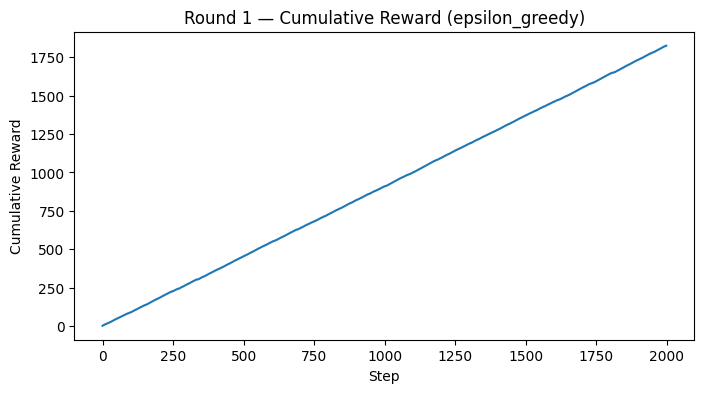

In [ ]:
# === YOUR SETTINGS (edit) ===
NAME = "super_seed_8"
STRATEGY = "epsilon_greedy"  # options: "epsilon_greedy" or "epsilon_greedy_decaying"
STEPS = 2000

# For fixed ε
EPSILON = 0.01

# For decaying ε
EPS_START = 0.1
EPS_END = 0.01

# Agent RNG seed (can be None for randomness)
SEED_AGENT = 66

# === RUN ===
if STRATEGY == "epsilon_greedy":
    rewards, actions, Q, N = epsilon_greedy(TRUE_MEANS, steps=STEPS, epsilon=EPSILON, seed=SEED_AGENT)
    strat_desc = f"fixed_eps={EPSILON}"
elif STRATEGY == "epsilon_greedy_decaying":
    rewards, actions, Q, N = epsilon_greedy_decaying(TRUE_MEANS, steps=STEPS, eps_start=EPS_START, eps_end=EPS_END, seed=SEED_AGENT)
    strat_desc = f"decay_eps={EPS_START}->{EPS_END}"
else:
    raise ValueError("Unknown STRATEGY setting")

total = float(np.sum(rewards))
best_arm_est = int(np.argmax(Q))
print(f"""
Player: {NAME}
Strategy: {STRATEGY} ({strat_desc})
Steps: {STEPS}
Total Reward: {total:.0f}
Estimated Best Arm: {best_arm_est}
Estimated Q: {np.round(Q,3)}
Counts N: {N.astype(int)}
""")
plot_cumulative(rewards, title=f"Round 1 — Cumulative Reward ({STRATEGY})")


Player Name     | Strategy                  | Parameters      | Total Reward
---------------------------------------------------------------------------
super_seed      | epsilon_greedy_decaying   | 0.9    -> 0.01 | 1484
super_seed_1    | epsilon_greedy_decaying   | 0.5    -> 0.01 | 1660
super_seed_2    | epsilon_greedy_decaying   | 0.2    -> 0.01 | 1764
super_seed_3    | epsilon_greedy_decaying   | 0.1    -> 0.01 | 1788
super_seed_4    | epsilon_greedy            | 0.9    -> None | 1164
super_seed_5    | epsilon_greedy            | 0.5    -> None | 1431
super_seed_6    | epsilon_greedy            | 0.2    -> None | 1681
super_seed_7    | epsilon_greedy            | 0.1    -> None | 1753
super_seed_8    | epsilon_greedy            | 0.01   -> None | 1826


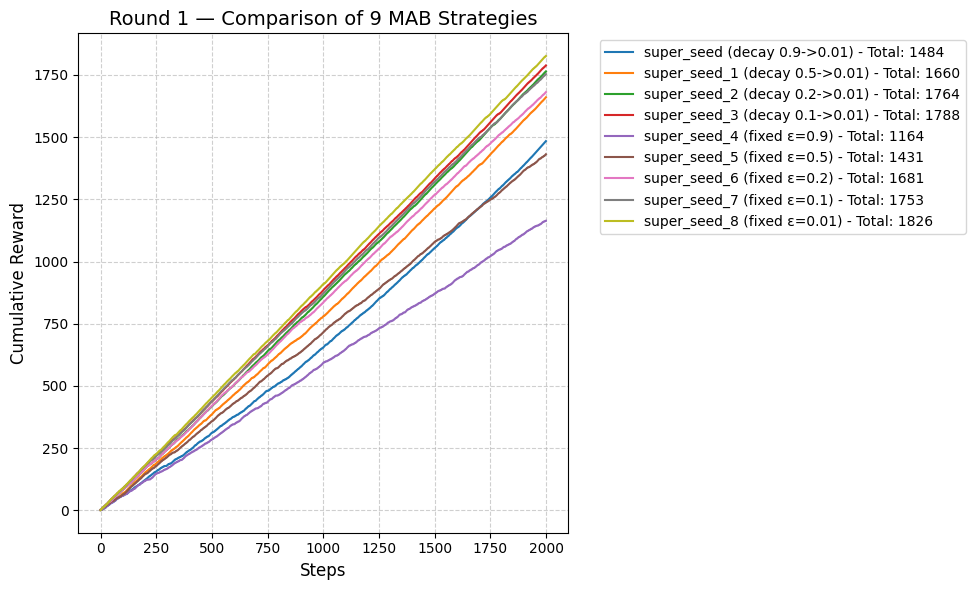

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 定義你要比較的 9 組實驗設定 (實驗名稱, 策略類型, 參數1, 參數2)
experiments = [
    # 遞減型策略 (Decaying Epsilon)
    ("super_seed", "epsilon_greedy_decaying", 0.9, 0.01),
    ("super_seed_1", "epsilon_greedy_decaying", 0.5, 0.01),
    ("super_seed_2", "epsilon_greedy_decaying", 0.2, 0.01),
    ("super_seed_3", "epsilon_greedy_decaying", 0.1, 0.01),
    
    # 固定型策略 (Fixed Epsilon)
    ("super_seed_4", "epsilon_greedy", 0.9, None),
    ("super_seed_5", "epsilon_greedy", 0.5, None),
    ("super_seed_6", "epsilon_greedy", 0.2, None),
    ("super_seed_7", "epsilon_greedy", 0.1, None),
    ("super_seed_8", "epsilon_greedy", 0.01, None)
]

STEPS = 2000
SEED_AGENT = 66

# 準備畫圖
plt.figure(figsize=(10, 6))

print(f"{'Player Name':<15} | {'Strategy':<25} | {'Parameters':<15} | {'Total Reward':<12}")
print("-" * 75)

# 2. 開始自動循環跑 9 組實驗
for name, strategy, param1, param2 in experiments:
    
    if strategy == "epsilon_greedy":
        # param1 在這裡代表固定的 EPSILON
        rewards, actions, Q, N = epsilon_greedy(TRUE_MEANS, steps=STEPS, epsilon=param1, seed=SEED_AGENT)
        label_desc = f"{name} (fixed ε={param1})"
        
    elif strategy == "epsilon_greedy_decaying":
        # param1=EPS_START, param2=EPS_END
        rewards, actions, Q, N = epsilon_greedy_decaying(TRUE_MEANS, steps=STEPS, eps_start=param1, eps_end=param2, seed=SEED_AGENT)
        label_desc = f"{name} (decay {param1}->{param2})"
        
    # 計算累積獎勵 (Cumulative Reward)
    cumulative_rewards = np.cumsum(rewards)
    total_reward = np.sum(rewards)
    
    # 印出文字結果
    print(f"{name:<15} | {strategy:<25} | {str(param1):<6} -> {str(param2):<4} | {total_reward:.0f}")
    
    # 3. 將這一組的折線加入圖中
    plt.plot(cumulative_rewards, label=f"{label_desc} - Total: {int(total_reward)}")

# 4. 圖表裝飾與顯示
plt.title("Round 1 — Comparison of 9 MAB Strategies", fontsize=14)
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Cumulative Reward", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # 把標籤框放在圖外面才不會擋到線
plt.tight_layout()
plt.show()


### 🧮 Submit to Leaderboard (Round 1)

This writes your result to a local CSV (`submissions_round1.csv`) in the current folder.  
The instructor can collect these files or run the next cell to view a local leaderboard.


In [31]:

import csv

lb_path = Path("submissions_round1.csv")
lb_exists = lb_path.exists()

row = {
    "timestamp": datetime.utcnow().isoformat(),
    "name": NAME,
    "strategy": STRATEGY,
    "details": strat_desc,
    "steps": STEPS,
    "seed_env": SEED_ENV,
    "seed_agent": SEED_AGENT,
    "total_reward": int(np.sum(rewards))
}

fieldnames = ["timestamp","name","strategy","details","steps","seed_env","seed_agent","total_reward"]

with open(lb_path, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    if not lb_exists:
        writer.writeheader()
    writer.writerow(row)

print("Submitted to", lb_path.resolve())


Submitted to L:\Reinforcement Learning Programming\MultiArmedBandit_Workshop\submissions_round1.csv


C:\Users\atat7\AppData\Local\Temp\ipykernel_7060\2191877043.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


In [32]:
import pandas as pd
from IPython.display import display

lb_path = Path("submissions_round1.csv")

if lb_path.exists():
    df = pd.read_csv(lb_path)
    df_sorted = df.sort_values("total_reward", ascending=False).reset_index(drop=True)
    print("🏆 Round 1 Leaderboard (sorted by total reward):")
    display(df_sorted)
else:
    print("No submissions yet. Run the previous cell to submit your score.")


🏆 Round 1 Leaderboard (sorted by total reward):


,timestamp,name,strategy,details,steps,seed_env,seed_agent,total_reward
0,2026-06-26T14:15:09.917874,super_seed_8,epsilon_greedy,fixed_eps=0.01,2000,66,66,1826
1,2026-06-26T14:11:51.747326,super_seed_3,epsilon_greedy_decaying,decay_eps=0.1->0.01,2000,66,66,1788
2,2026-06-26T14:10:10.302047,super_seed_2,epsilon_greedy_decaying,decay_eps=0.2->0.01,2000,66,66,1764
3,2026-06-26T14:14:53.330774,super_seed_7,epsilon_greedy,fixed_eps=0.1,2000,66,66,1753
4,2026-06-26T14:13:12.845280,super_seed_6,epsilon_greedy,fixed_eps=0.2,2000,66,66,1681
5,2026-06-26T14:09:31.460239,super_seed_1,epsilon_greedy_decaying,decay_eps=0.5->0.01,2000,66,66,1660
6,2026-06-26T14:08:12.111672,super_seed,epsilon_greedy_decaying,decay_eps=0.9->0.01,2000,66,66,1484
7,2026-06-26T14:12:58.412340,super_seed_5,epsilon_greedy,fixed_eps=0.5,2000,66,66,1431
8,2026-06-26T14:12:33.112910,super_seed_4,epsilon_greedy,fixed_eps=0.9,2000,66,66,1164



## 🧠 Step 6 — Reflect & Discuss (for your notes / debrief)

1. **What strategy did you use and why?**  
2. **How did ε influence your total reward?** Did you try multiple ε values?
3. **Did your agent get “stuck” exploiting too soon?** How could you prevent that?
4. **If you had more steps, what would you change (ε schedule, update rule, etc.)?**
5. **Compare with others:** Did randomness or design matter more for the winners?
6. **Transfer:** Where would this exploration dilemma appear in real systems (recsys, A/B testing, ads)?


## Answer 6
1. **What strategy did you use and why?**  

* I tried two strategies: `epsilon_greedy_decaying` and `epsilon_greedy`. I wanted to compare how a fixed exploration rate and a decaying exploration rate change my total reward.

2. **How did ε influence your total reward?** Did you try multiple ε values?

* Yes, I tried multiple $\epsilon$ values (0.9, 0.5, 0.2, 0.1, and 0.01).
* In `epsilon_greedy`, when $\epsilon$ is big (0.9), the score is very low (1164). When $\epsilon$ is small (0.01), the score is very high (1826). This is because less exploration means more time to choose the best arm and get rewards.
* In `epsilon_greedy_decaying`, a smaller start $\epsilon$ (0.1) gave a better reward (1788) than a bigger start $\epsilon$ (0.9 -> 1484). Too much exploration in the beginning wastes many steps on bad machines.

3. **Did your agent get “stuck” exploiting too soon?** How could you prevent that?

* In my experiment, the agent with fixed `ε=0.01` did not get stuck. It found the best machine very quickly by luck and got the highest score (1826).
* However, starting with a very small $\epsilon$ (like 0.01) is dangerous. If the agent has bad luck at the start, it will get "stuck" on a bad machine because it does not try other machines.
* To prevent this, we need Initial Exploration (maybe 500?). This means the agent explores more in the beginning to find the true best machine. We can do this by using a decaying strategy, like `decay 0.2->0.01` or `decay 0.1->0.01`. This design forces the agent to try more machines at the start, so it does not get stuck too soon.

4. **If you had more steps, what would you change (ε schedule, update rule, etc.)?**

* If I had more steps (like 5000 steps), I would change the strategy to `decay 0.5->0.01`.
* In my chart: in the first 500 steps, the `decay 0.5` line is low because it spends too much time exploring. But after 1000 steps, its line becomes steeper (climbing faster) because it found the best machine and started exploiting.
* If the game has more steps, the line will have more time to exploit and will eventually beat the other lines.

5. **Compare with others:** Did randomness or design matter more for the winners?

* Both matter, and my chart proves it:Design matters: 
* If we compare `decay 0.1->0.01` (1788) and fixed `ε=0.1` (1753), they start with the same exploration rate. But the decaying design wins because it reduces $\epsilon$ later to avoid wasting steps.
* Randomness matters: My fixed `ε=0.01` got the highest score (1826). This is purely because of a lucky random seed (seed_agent=66). In real life, we cannot always trust luck, so a good strategy design is more reliable.

6. **Transfer:** Where would this exploration dilemma appear in real systems (recsys, A/B testing, ads)?

* This dilemma happens a lot in real life:
* Recommendation Systems (like YouTube or TikTok): The system needs to exploit what I like (showing me my favorite videos) but also explore new types of videos so I do not get bored.
* Online Ads: Companies need to exploit the best ad that gets many clicks, but they also need to explore new ad designs to see if they can perform better.



## 📊 Experiment: Compare Different ε Values (Optional)

Run multiple ε settings to *see* the exploration trade‑off.


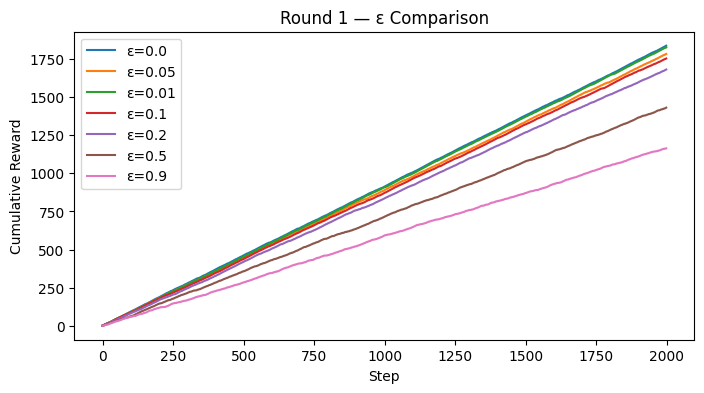

In [35]:

eps_list = [0.0, 0.05, 0.01, 0.1, 0.2, 0.5, 0.9]
curves = {}
for eps in eps_list:
    r, _, _, _ = epsilon_greedy(TRUE_MEANS, steps=STEPS, epsilon=eps, seed=SEED_AGENT)
    curves[eps] = np.cumsum(r)

plt.figure()
for eps, curve in curves.items():
    plt.plot(curve, label=f"ε={eps}")
plt.legend()
plt.xlabel("Step")
plt.ylabel("Cumulative Reward")
plt.title("Round 1 — ε Comparison")
plt.show()



# 🔄 Round 2 — Non‑Stationary Casino (Competition)

**Twist:** The slot machines drift over time. Fixed exploitation can fail; adaptive exploration helps.

Two common adaptations:
- Keep **ε** from decaying too low (retain exploration).
- Use a **constant step size α** (exponential moving average) to weight recent rewards more.


In [37]:

def nonstationary_means(n_arms=10, seed=66):
    # Initialize random means
    rng = np.random.default_rng(seed)
    return rng.random(n_arms)

def step_drift(means, drift_scale=0.01, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    means = means + rng.normal(0, drift_scale, size=means.shape)
    return np.clip(means, 0.0, 1.0)

def epsilon_greedy_constant_alpha(steps=2000, n_arms=10, eps=0.1, alpha=0.1, seed_env=7, seed_agent=None, drift_scale=0.01):
    # Non-stationary env with drifting means
    rng_env = np.random.default_rng(seed_env)
    rng_agent = np.random.default_rng(seed_agent)
    means = rng_env.random(n_arms)
    Q = np.zeros(n_arms)
    rewards = np.zeros(steps, dtype=float)
    actions = np.zeros(steps, dtype=int)
    for t in range(steps):
        # choose action
        if rng_agent.random() < eps:
            a = rng_agent.integers(0, n_arms)
        else:
            a = int(np.argmax(Q))
        # reward from current means
        r = 1.0 if rng_env.random() < means[a] else 0.0
        # constant step-size update (EMA)
        Q[a] = Q[a] + alpha * (r - Q[a])
        rewards[t] = r
        actions[t] = a
        # drift environment
        means = step_drift(means, drift_scale=drift_scale, rng=rng_env)
    return rewards, actions, Q



[Round 2]
Player: SSuper_seed_7
Strategy: epsilon_greedy + constant_alpha (eps=0.1, alpha=0.01)
Steps: 3000
Total Reward: 2497



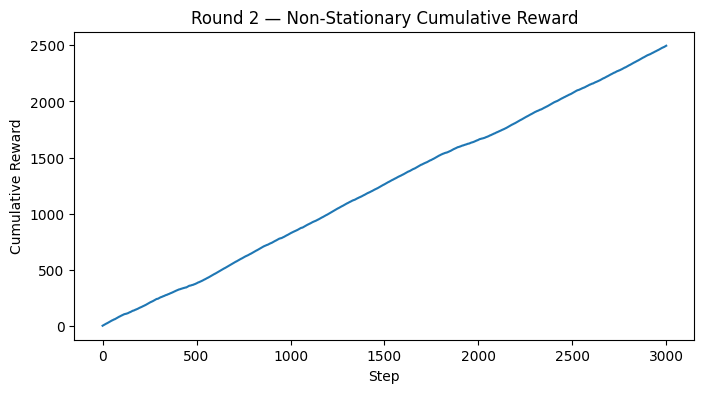

In [ ]:

# === YOUR SETTINGS (edit) ===
NAME_R2 = "SSuper_seed_7"
STEPS_R2 = 3000
EPS_R2 = 0.1     # keep some exploration alive
ALPHA_R2 = 0.01   # constant step size for non-stationarity
SEED_ENV_R2 = 66  # shared across class
SEED_AGENT_R2 = 666
DRIFT_SCALE = 0.01  # magnitude of mean drift per step

# === RUN ===
rewards_r2, actions_r2, Q_r2 = epsilon_greedy_constant_alpha(
    steps=STEPS_R2, n_arms=10, eps=EPS_R2, alpha=ALPHA_R2,
    seed_env=SEED_ENV_R2, seed_agent=SEED_AGENT_R2, drift_scale=DRIFT_SCALE
)

total_r2 = int(np.sum(rewards_r2))
print(f"""
[Round 2]
Player: {NAME_R2}
Strategy: epsilon_greedy + constant_alpha (eps={EPS_R2}, alpha={ALPHA_R2})
Steps: {STEPS_R2}
Total Reward: {total_r2}
""")
plot_cumulative(rewards_r2, title="Round 2 — Non‑Stationary Cumulative Reward")


In [60]:

import csv
lb2_path = Path("submissions_round2.csv")
lb2_exists = lb2_path.exists()

row2 = {
    "timestamp": datetime.utcnow().isoformat(),
    "name": NAME_R2,
    "strategy": f"eps={EPS_R2}, alpha={ALPHA_R2}",
    "steps": STEPS_R2,
    "seed_env": SEED_ENV_R2,
    "seed_agent": SEED_AGENT_R2,
    "drift_scale": DRIFT_SCALE,
    "total_reward": total_r2
}

fieldnames2 = ["timestamp","name","strategy","steps","seed_env","seed_agent","drift_scale","total_reward"]

with open(lb2_path, "a", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames2)
    if not lb2_exists:
        writer.writeheader()
    writer.writerow(row2)

print("Submitted to", lb2_path.resolve())


Submitted to L:\Reinforcement Learning Programming\MultiArmedBandit_Workshop\submissions_round2.csv


C:\Users\atat7\AppData\Local\Temp\ipykernel_7060\2415904048.py:6: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat(),


In [61]:
import pandas as pd
from IPython.display import display

lb_path = Path("submissions_round2.csv")

if lb_path.exists():
    df = pd.read_csv(lb_path)
    df_sorted = df.sort_values("total_reward", ascending=False).reset_index(drop=True)
    print("🏆 Round 1 Leaderboard (sorted by total reward):")
    display(df_sorted)
else:
    print("No submissions yet. Run the previous cell to submit your score.")


🏆 Round 1 Leaderboard (sorted by total reward):


,timestamp,name,strategy,steps,seed_env,seed_agent,drift_scale,total_reward
0,2026-06-26T15:07:34.879106,SSuper_seed_3,"eps=0.1, alpha=0.1",3000,66,666,0.01,2594
1,2026-06-26T15:07:59.750562,SSuper_seed_4,"eps=0.01, alpha=0.1",3000,66,666,0.01,2584
2,2026-06-26T15:09:05.304201,SSuper_seed_6,"eps=0.1, alpha=0.5",3000,66,666,0.01,2557
3,2026-06-26T15:08:41.823219,SSuper_seed_5,"eps=0.1, alpha=0.9",3000,66,666,0.01,2556
4,2026-06-26T15:10:04.281377,SSuper_seed_7,"eps=0.1, alpha=0.01",3000,66,666,0.01,2497
5,2026-06-26T15:07:12.837576,SSuper_seed_2,"eps=0.5, alpha=0.1",3000,66,666,0.01,2216
6,2026-06-26T15:06:50.437665,SSuper_seed_1,"eps=0.9, alpha=0.1",3000,66,666,0.01,1743


Experiment Name    | Epsilon (eps) | Alpha (alpha) | Total Reward
-----------------------------------------------------------------
SSuper_seed_1      | 0.9           | 0.1           | 1743
SSuper_seed_2      | 0.5           | 0.1           | 2216
SSuper_seed_3      | 0.1           | 0.1           | 2594
SSuper_seed_4      | 0.01          | 0.1           | 2584
SSuper_seed_5      | 0.1           | 0.9           | 2556
SSuper_seed_6      | 0.1           | 0.5           | 2557
SSuper_seed_7      | 0.1           | 0.01          | 2497


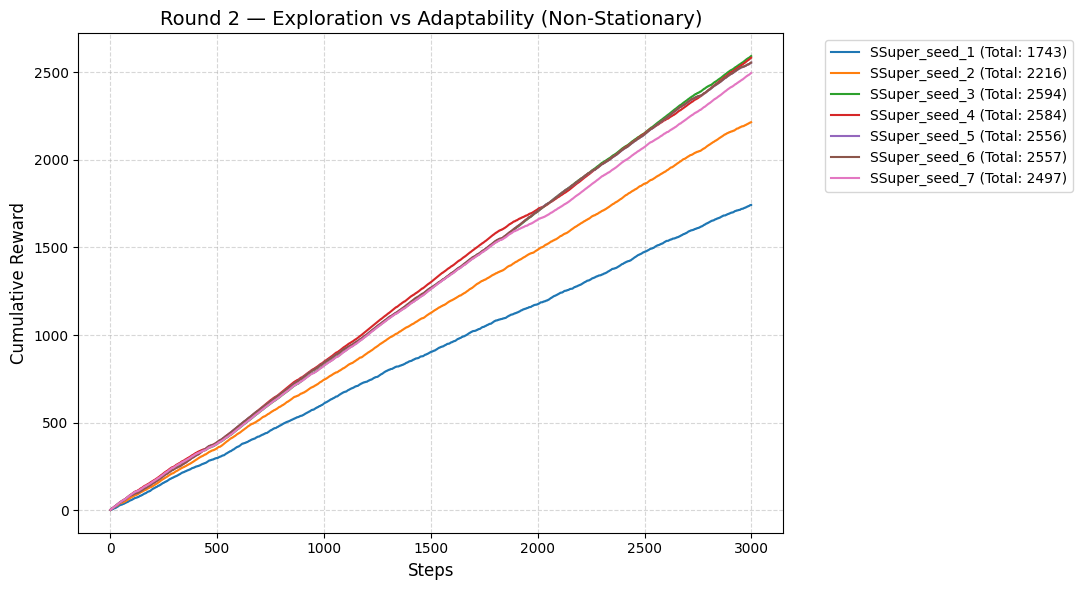

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# 設定與原程式一致的基礎參數
STEPS_R2 = 3000
SEED_ENV_R2 = 66
SEED_AGENT_R2 = 666
DRIFT_SCALE = 0.01

experiments_r2 = [
    # Test 1: Exploration (fixed Alpha = 0.1, varying Epsilon)
    ("SSuper_seed_1", 0.9,  0.1),
    ("SSuper_seed_2", 0.5,  0.1),
    ("SSuper_seed_3", 0.1,  0.1),
    ("SSuper_seed_4", 0.01, 0.1),
    
    # Test 2: Adaptability (fixed Epsilon = 0.1, varying Alpha)
    ("SSuper_seed_5", 0.1,  0.9),
    ("SSuper_seed_6", 0.1,  0.5),
    ("SSuper_seed_7", 0.1,  0.01)
]

# 準備畫圖
plt.figure(figsize=(11, 6))

print(f"{'Experiment Name':<18} | {'Epsilon (eps)':<13} | {'Alpha (alpha)':<13} | {'Total Reward':<12}")
print("-" * 65)

# 2. 開始自動循環運行實驗
for name, eps, alpha in experiments_r2:
    
    # 呼叫你定義好的非靜態環境函式
    rewards_r2, actions_r2, Q_r2 = epsilon_greedy_constant_alpha(
        steps=STEPS_R2, n_arms=10, eps=eps, alpha=alpha,
        seed_env=SEED_ENV_R2, seed_agent=SEED_AGENT_R2, drift_scale=DRIFT_SCALE
    )
    
    total_reward_r2 = int(np.sum(rewards_r2))
    cumulative_rewards_r2 = np.cumsum(rewards_r2)
    
    # 輸出文字報表
    print(f"{name:<18} | {eps:<13} | {alpha:<13} | {total_reward_r2:.0f}")
    
    # 3. 繪製這一組的折線
    # 為了方便你在報告裡對照，標籤會同時顯示名稱與該組的總分
    plt.plot(cumulative_rewards_r2, label=f"{name} (Total: {total_reward_r2})")

# 4. 圖表外觀裝飾與優化
plt.title("Round 2 — Exploration vs Adaptability (Non-Stationary)", fontsize=14)
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Cumulative Reward", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # 標籤放在圖外面，不遮擋折線
plt.tight_layout()
plt.show()

### **Test 1: The Importance of Exploration (Fixed $\alpha = 0.1$)**

| Player Name | Epsilon ($\epsilon$) | Alpha ($\alpha$) | Total Reward |
| :--- | :---: | :---: | :---: |
| **SSuper_seed_1** | 0.9 | 0.1 | 1743 |
| **SSuper_seed_2** | 0.5 | 0.1 | 2216 |
| **SSuper_seed_3** (Best) | **0.1** | **0.1** | **2594** |
| **SSuper_seed_4** | 0.01 | 0.1 | 2584 |

### **Test 2: The Importance of Constant $\alpha$ (Fixed $\epsilon = 0.1$)**

| Player Name | Epsilon ($\epsilon$) | Alpha ($\alpha$) | Total Reward |
| :--- | :---: | :---: | :---: |
| **SSuper_seed_7** | 0.1 | 0.01 | 2497 |
| **SSuper_seed_3** (Best) | **0.1** | **0.1** | **2594** |
| **SSuper_seed_6** | 0.1 | 0.5 | 2557 |
| **SSuper_seed_5** | 0.1 | 0.9 | 2556 |

## Summary 

* **1. Round 1 (Static Environment)**
    * When the casino does not change, **less exploration is better** (固定 $\epsilon = 0.01$ got the highest score: 1826).
    * **The Reason:** After the agent finds the best machine, it should stop trying other machines and focus on making money.

* **2. Round 2 (Changing Environment)**
    * When the casino changes over time, **we must keep exploring** (`eps=0.1` got 2594, which is better than `eps=0.01`).
    * **The Reason:** If the agent stops exploring, it will get "stuck" on an old machine when that machine becomes bad.
    * **The Alpha ($\alpha$) Rule:** A medium $\alpha$ (0.1) is the best. It helps the agent forget old data and learn new changes quickly.

* **3. Conclusion**
    * **In a stable world**, we should exploit more and explore less.
    * **In a changing world**, we must always explore a little bit and update our memory fast.


## 🧪 Bonus (Optional): Compete with UCB or Thompson Sampling

If allowed by the instructor, try implementing:
- **UCB1 (Upper Confidence Bound):** add an optimism bonus to less‑tried arms.
- **Thompson Sampling:** maintain Beta posteriors for each arm and sample to choose.

> Keep Round 1/2 seeds the same for comparability.



---

### ✅ Submission Notes for Instructors
- Each student’s notebook writes a local CSV (`submissions_round1.csv` / `submissions_round2.csv`).  
  Collect these files or ask students to paste rows into a shared sheet for a class-wide leaderboard.
- **Fairness:** Keep `SEED_ENV` (Round 1) and `SEED_ENV_R2` (Round 2) fixed across all students.
- **Assessment Ideas:** Award badges like *Risk Taker* (highest ε with solid score), *Efficient Exploiter*, *Adaptive Strategist* (best in Round 2).

### 🧠 Learning Outcomes
- Understand & visualize the exploration–exploitation trade‑off.
- See why ε matters, and why **constant‑α** helps in non‑stationary settings.
- Practice experimental design (controlled seeds, fair comparisons, parameter sweeps).

Happy bandit hunting! 🎲
